# Customer Churn Prediction in Interconnect
**Data Science & Predictive Analytics Project**

## Introducción y Objetivos de Negocio
El objetivo principal de este proyecto es construir un modelo predictivo capaz de identificar proactivamente a los clientes de la empresa de telecomunicaciones **Interconnect** que planean cancelar sus servicios (*churn*). Esto permitirá al equipo de marketing actuar de manera anticipada ofreciéndoles códigos promocionales y planes especiales de retención.

* **Métrica Principal de Éxito:** AUC-ROC (Meta establecida: $\ge$ 0.88 para la máxima calificación).

* **Métrica Secundaria:** Exactitud (Accuracy).

---

## Plan de Trabajo

Para resolver con éxito la tarea de modelado y cumplir con los requisitos del negocio, se ejecutará un plan estructurado en los siguientes 6 pasos clave:

1. **Aislamiento de Infraestructura: Entorno Virtual `tabular_class_env`:**

    Antes de realizar cualquier manipulación de datos, la metodología científica dicta establecer un entorno de ejecución aislado y especializado. Este proyecto pertenece a la categoría de **Clasificación Binaria basada en Datos Tabulares Estructurados**. 

    La naturaleza tabular exige un ecosistema optimizado para el álgebra lineal, el procesamiento de matrices dispersas y algoritmos de boosting basados en árboles de decisión, combinados de forma híbrida con frameworks de aprendizaje profundo. Por ello, se ha diseñado y desplegado el entorno virtual **`tabular_classification`** con las siguientes características:

    * **Lenguaje Python (`Python 3.11`).**

    * **Procesamiento Basal y Análisis Exploratorio (`pandas` y `numpy`).**

    * **Modelado Predictivo Convencional y Ensambles (`scikit-learn`).**

    * **Gradient Boosting Tabular Especializado (`lightgbm`).**

    * **Deep Learning Tabular Adaptado para chip M1 (`tensorflow 2.15.0` y `tensorflow-metal 1.1.0`).**

<br>
<div style="display: flex; justify-content: center; padding: 0 15px;">
<pre style="text-align: left; padding: 15px; border-radius: 5px; border: 1px solid #e1e4e6; background-color: #fff; display: inline-block; color: #000">
conda create -n tab_class python=3.11 -y
conda activate tab_class
conda install -c conda-forge scikit-learn pandas numpy matplotlib seaborn -y
pip install lightgbm
pip install tensorflow==2.15.0 tensorflow-metal==1.1.0</pre>
</div>

Finalmente documentará las librerías:

<br>
<div style="display: flex; justify-content: center;">
<pre style="text-align: left; padding: 15px; border-radius: 5px; border: 1px solid #e1e4e6; background-color: #fff; display: inline-block; color: #000">
pip freeze > requirements.txt</pre>
</div>

2. **Análisis Exploratorio de Datos (EDA) y Diagnóstico Basal:**
    
    Consiste en cargar las 4 fuentes de datos (`contract`, `personal`, `internet`, `phone`), unificar las dimensiones mediante la llave `customerID`, inspeccionar nulos, tipos de datos incorrectos y evaluar el desequilibrio de la característica objetivo.
<br>

3. **Ingeniería de Características (Feature Engineering) y Limpieza:**

    Se construirá la variable objetivo (`churn`) a partir de la columna `EndDate` y se creará una variable fundamental de *antigüedad del cliente* calculando los días/meses transcurridos desde `BeginDate` hasta la fecha de corte o cancelación; además se tratarán los nulos generados por la ausencia de servicios cruzados.
<br>

4. **Preparación de Datos y División de Conjuntos:**

    Involucra remover características que generen fuga de datos (*Data Leakage*) como fechas exactas e identificadores, codificar las variables categóricas (usando One-Hot Encoding o codificación de etiquetas) y dividir el dataset de manera estratificada en conjuntos de entrenamiento y prueba (80/20).
<br>

5. **Entrenamiento Iterativo y Optimización de Modelos:**

    Se establecerá un modelo base (Regresión Logística) y posteriormente se entrenarán y tunearán algoritmos avanzados de ensamble y Gradient Boosting (`Random Forest`, `LightGBM`), buscando mediante optimización de hiperparámetros maximizar la métrica AUC-ROC.
<br>    

6. **Evaluación Final y Redacción del Informe:**

    Se evaluará el modelo ganador con el conjunto de prueba independiente para validar su capacidad de generalización, se graficará la curva ROC, se analizará la importancia de las características predictivas y se formularán las recomendaciones comerciales definitivas.

---

## Preguntas para Discusión con el Líder de Equipo

Antes de proceder con el modelado profundo, es necesario discutir y aclarar los siguientes puntos clave sobre las reglas del negocio y el manejo del dataset:

1. **Definición de la Fecha de Corte para Clientes Activos:** Para los clientes que no han cancelado el servicio (`EndDate == 'No'`), ¿cuál es la fecha exacta que debemos considerar como el "presente" para calcular su antigüedad? Asumimos provisionalmente el **1 de febrero de 2020** debido a la indicación en la descripción del dataset, pero requerimos confirmación.

2. **Naturaleza de los Valores Vacíos en `TotalCharges`:** Se observa que algunos clientes tienen un espacio en blanco en la columna de cargos totales. ¿Esto se debe a que son clientes completamente nuevos que contrataron el servicio en el último mes disponible y aún no generan su primera factura? ¿Es correcto imputar estos valores con `0` o con el valor de su `MonthlyCharges`?

3. **Estrategia ante el Desequilibrio de Clases:** Tradicionalmente los datasets de Churn presentan un fuerte desequilibrio (muchos clientes activos, pocos que cancelan). ¿Existe alguna preferencia institucional por el uso de técnicas de remuestreo como `SMOTE`, submuestreo, o preferimos balancear el modelo únicamente mediante los parámetros internos de los algoritmos (ej. `class_weight='balanced'`)?

4. **Umbral Mínimo Comercial para la Toma de Decisiones:** Para el equipo de marketing, ¿es más crítico evitar los Falsos Negativos (clientes que se van a ir pero el modelo dice que se quedan) o los Falsos Positivos (clientes leales a los que les regalaremos promociones sin necesidad)? Esto nos ayudará a tunear el umbral de probabilidad óptimo más allá de la métrica puramente estadística AUC-ROC.

---

## Inicialización

In [1]:
# Librerías

## Manipulación de texto y expresiones regulares
import re

## Manipulación de datos y operaciones numéricas
import pandas as pd
import numpy as np

## Visualización de datos y gráficos estadísticos
import matplotlib.pyplot as plt
import seaborn as sns

## Preparación de datos, codificación y escalado
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

## Métricas de Evaluación
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score

## Los modelos de batalla (Modelado Predictivo)
from sklearn.linear_model import LogisticRegression             # 1. Escuela Lineal

from sklearn.ensemble import RandomForestClassifier             # 2. Escuela de Árboles

from lightgbm import LGBMClassifier                             # 3. Escuela de Gradient Boosting

import tensorflow as tf                                         # 4. Escuela de Deep Learning (ANN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam as LegacyAdam   # Optimizado para chip M1
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

import keras_tuner as kt

## Configuraciones de entorno y supresión de alertas
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("¡Todas las librerías del ecosistema cargadas exitosamente!")

# Rutas de archivos
path_contract = 'datasets/contract.csv'
path_personal = 'datasets/personal.csv'
path_internet = 'datasets/internet.csv'
path_phone = 'datasets/phone.csv'

¡Todas las librerías del ecosistema cargadas exitosamente!


## Análisis Exploratorio de Datos (EDA)

En esta sección realizaremos la carga individual de las 4 fuentes de datos de Interconnect. El objetivo es inspeccionar las dimensiones de cada tabla, validar los tipos de datos asignados por defecto, identificar la presencia de valores nulos o registros duplicados, y detectar posibles inconsistencias estructurales (como tipos numéricos interpretados como texto) antes de proceder con la ingeniería de características y la consolidación del dataset definitivo.

---

### Carga de datos

In [2]:
# Carga de los conjuntos de datos independientes
try:
    df_contract = pd.read_csv(path_contract)
    df_personal = pd.read_csv(path_personal)
    df_internet = pd.read_csv(path_internet)
    df_phone = pd.read_csv(path_phone)
    print("¡Los 4 archivos CSV han sido cargados exitosamente en el entorno!")
except FileNotFoundError as e:
    print(f"Error en la ruta de archivos: {e}")

¡Los 4 archivos CSV han sido cargados exitosamente en el entorno!


In [3]:
# Diccionarios para automatizar la revisión de los dataframes
datasets = {
    'contract': {'df': df_contract, 'name': 'Contract (Contratos)'},
    'personal': {'df': df_personal, 'name': 'Personal (Datos Personales)'},
    'internet': {'df': df_internet, 'name': 'Internet (Servicios Web)'},
    'phone': {'df': df_phone, 'name': 'Phone (Servicios Telefónicos)'}
}

### Estructura general de tablas

In [4]:
# Estructura general de las tablas
print("\n=== Estructura General de los DataFrames ===")
for key, values in datasets.items():
    print(f"\nDataFrame: {values['name']}")
    print(values['df'].info())


=== Estructura General de los DataFrames ===

DataFrame: Contract (Contratos)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   BeginDate         7043 non-null   str    
 2   EndDate           7043 non-null   str    
 3   Type              7043 non-null   str    
 4   PaperlessBilling  7043 non-null   str    
 5   PaymentMethod     7043 non-null   str    
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   str    
dtypes: float64(1), str(7)
memory usage: 440.3 KB
None

DataFrame: Personal (Datos Personales)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str 

A partir de la información estructural extraída de las 4 fuentes de datos, podemos identificar inconsistencias y patrones clave que justifican una fase inmediata de saneamiento antes de proceder con el modelado:

* **Inconsistencia de Estilos y Formatos (`camelCase` y `PascalCase`):** Podemos ver que los nombres de las columnas y las variables categóricas arrastran una mezcla de nomenclaturas heredadas (como `customerID`, `PaymentMethod` u `OnlineSecurity`), además de valores de texto con mayúsculas iniciales y caracteres especiales como paréntesis en los métodos automáticos (`Bank transfer (automatic)`). Por lo tanto, más adelante se hará una normalización global donde tanto las columnas como el vocabulario interno se transformarán estrictamente a minúsculas y formato `snake_case` para garantizar la homogeneidad del dataset.

* **Naturaleza del Negocio y Disparidad en las Dimensiones:** Podemos ver que mientras `contract` y `personal` cubren a la población total de 7,043 clientes, las tablas de servicios específicos como `internet` (5,517) y `phone` (6,361) poseen menos registros. Esto refleja que muchos usuarios solo contratan un servicio y no ambos de manera cruzada. Por lo tanto, más adelante se tendrá un cuidado quirúrgico al realizar la fusión de datos mediante un *Join* por `customer_id`, ya que los valores nulos resultantes no representarán errores de captura, sino la ausencia legítima de ese servicio para el cliente, debiendo ser imputados de forma segura con la categoría `'no'`.

* **Anomalía en la Variable Financiera (`TotalCharges`):** Podemos ver que, a pesar de representar cargos económicos acumulados, la columna `TotalCharges` está clasificada como tipo objeto (`str`) debido a la presencia de espacios en blanco ocultos en clientes completamente nuevos que aún no cierran su primer ciclo de facturación. Por lo tanto, más adelante se hará una coerción forzada a tipo numérico (`float64`) y se imputarán esos registros vacíos con un valor de `0.0`, blindando la variable para los algoritmos lineales y la red neuronal.

---

### Diagnóstico de dimensiones y duplicados

In [5]:
# Diagnóstico de dimensiones y duplicados
print("\n=== Diagnóstico Dimensional de los DataFrames ===")
for key, values in datasets.items():
    print(f"\nDataFrame: {values['name']}")
    print(f"  - Dimensiones (Filas, Columnas): {values['df'].shape}")
    print(f"  - ID Únicos (customerID): {values['df']['customerID'].nunique()}")
    print(f"  - Registros completamente duplicados: {values['df'].duplicated().sum()}")


=== Diagnóstico Dimensional de los DataFrames ===

DataFrame: Contract (Contratos)
  - Dimensiones (Filas, Columnas): (7043, 8)
  - ID Únicos (customerID): 7043
  - Registros completamente duplicados: 0

DataFrame: Personal (Datos Personales)
  - Dimensiones (Filas, Columnas): (7043, 5)
  - ID Únicos (customerID): 7043
  - Registros completamente duplicados: 0

DataFrame: Internet (Servicios Web)
  - Dimensiones (Filas, Columnas): (5517, 8)
  - ID Únicos (customerID): 5517
  - Registros completamente duplicados: 0

DataFrame: Phone (Servicios Telefónicos)
  - Dimensiones (Filas, Columnas): (6361, 2)
  - ID Únicos (customerID): 6361
  - Registros completamente duplicados: 0


A partir de las métricas dimensionales obtenidas, podemos ver que la columna `customerID` mantiene un conteo de valores únicos que coincide perfectamente con el total de filas de cada una de sus respectivas tablas. Asimismo, el conteo de registros completamente duplicados es estrictamente `0` de forma global. Por lo tanto, se descarta cualquier riesgo de redundancia o sesgo por duplicación en los datos basales, lo que nos garantiza que cada fila representa a un usuario único e independiente en el histórico de Interconnect.

---

### Muestra Aleatoria de Datos

In [6]:
# Muestra de datos
print("\n=== Muestra de Datos ===")
for key, values in datasets.items():
    print(f"\nDataFrame: {values['name']}")
    print(values['df'].sample(5, random_state=42))


=== Muestra de Datos ===

DataFrame: Contract (Contratos)
      customerID   BeginDate              EndDate            Type  \
185   1024-GUALD  2019-10-01  2019-11-01 00:00:00  Month-to-month   
2715  0484-JPBRU  2016-09-01                   No  Month-to-month   
3825  3620-EHIMZ  2015-10-01                   No        Two year   
1807  6910-HADCM  2019-09-01  2019-10-01 00:00:00  Month-to-month   
132   8587-XYZSF  2014-07-01                   No        Two year   

     PaperlessBilling              PaymentMethod  MonthlyCharges TotalCharges  
185               Yes           Electronic check           24.80         24.8  
2715              Yes  Bank transfer (automatic)           25.25       996.45  
3825               No               Mailed check           19.35       1031.7  
1807               No           Electronic check           76.35        76.35  
132                No  Bank transfer (automatic)           50.55       3260.1  

DataFrame: Personal (Datos Personales)
      

Al inspeccionar la muestra aleatoria de registros (`sample`), podemos ver de manera preliminar la estructura real de la información antes de ser procesada. Es evidente la discrepancia estética y técnica entre las variables: fechas que coexisten con cadenas de texto (como en `EndDate`), la variabilidad en los rangos de los cargos económicos, y la fragmentación de IDs entre servicios. Por lo tanto, esta vista preliminar justifica la necesidad obligatoria de descender a una revisión detallada de cada columna de forma aislada para estructurar un mapa de transformaciones quirúrgicas.

---

### Análisis de Características Categóricas

In [7]:
# Análisis de valores únicos en características categóricas

print("=== Valores únicos de características categóricas ===")

for key, values in datasets.items():
    print(f"Dataframe: {datasets[key]['name']}")
    
    ## Seleccionamos solo las columnas categóricas (tipo object / texto)
    ### Excluimos IDs, fecha inicial y cargas totales para no saturar la pantalla con miles de valores únicos
    categoric_cols = values['df'].select_dtypes(include=['object']).columns
    filtered_cols = [col for col in categoric_cols if col not in ['customerID', 'BeginDate', 'TotalCharges']]
    
    if len(filtered_cols) == 0:
        print("  (No hay columnas categóricas adicionales en esta tabla)")
        continue
        
    for col in filtered_cols:
        unique_values = values['df'][col].unique()
        print(f"\n* Columna: '{col}' ({len(unique_values)} valores únicos)")
        print(f"   {unique_values}")

=== Valores únicos de características categóricas ===
Dataframe: Contract (Contratos)

* Columna: 'EndDate' (5 valores únicos)
   <StringArray>
[                 'No', '2019-12-01 00:00:00', '2019-11-01 00:00:00',
 '2019-10-01 00:00:00', '2020-01-01 00:00:00']
Length: 5, dtype: str

* Columna: 'Type' (3 valores únicos)
   <StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

* Columna: 'PaperlessBilling' (2 valores únicos)
   <StringArray>
['Yes', 'No']
Length: 2, dtype: str

* Columna: 'PaymentMethod' (4 valores únicos)
   <StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
Dataframe: Personal (Datos Personales)

* Columna: 'gender' (2 valores únicos)
   <StringArray>
['Female', 'Male']
Length: 2, dtype: str

* Columna: 'Partner' (2 valores únicos)
   <StringArray>
['Yes', 'No']
Length: 2, dtype: str

* Columna: 'Dependents' (2 valores únicos)
   <StringArray

A través del escaneo automatizado de los valores únicos, podemos ver con total claridad las inconsistencias de formato que presenta el dataset. Destacan la presencia de mayúsculas y minúsculas cruzadas (`Month-to-month` frente a `DSL`), espacios intermedios y el uso de paréntesis descriptivos en los métodos de pago automáticos (`Bank transfer (automatic)`). Por lo tanto, más adelante se ejecutará un proceso estricto de sanitización masiva para remover caracteres especiales y normalizar tanto los nombres de las columnas como el vocabulario de texto al formato estándar de Python: minúsculas y `snake_case`.

---

### Análisis de la variable objetivo

In [8]:
# Análisis de desequilibrio basal en Contract antes de procesar el Target
print("=== DISTRIBUCIÓN ASOCIADA A LA CANCELACIÓN (EndDate) ===")
print(df_contract['EndDate'].value_counts(dropna=False))
print("\nPorcentaje de distribución:")
print(df_contract['EndDate'].value_counts(normalize=True) * 100)

# Investigación de la anomalía en TotalCharges (Validación de espacios vacíos)
empties = df_contract[df_contract['TotalCharges'].str.contains('^\s*$', na=False)]
print(f"\n[ALERTA TÉCNICA] Registros con espacios en blanco en 'TotalCharges': {len(empties)}")

if len(empties) > 0:
    print("\nMuestra de registros con TotalCharges vacío:")
    display(empties[['customerID', 'BeginDate', 'EndDate', 'MonthlyCharges', 'TotalCharges']].head(5))

=== DISTRIBUCIÓN ASOCIADA A LA CANCELACIÓN (EndDate) ===
EndDate
No                     5174
2019-11-01 00:00:00     485
2019-12-01 00:00:00     466
2020-01-01 00:00:00     460
2019-10-01 00:00:00     458
Name: count, dtype: int64

Porcentaje de distribución:
EndDate
No                     73.463013
2019-11-01 00:00:00     6.886270
2019-12-01 00:00:00     6.616499
2020-01-01 00:00:00     6.531308
2019-10-01 00:00:00     6.502911
Name: proportion, dtype: float64

[ALERTA TÉCNICA] Registros con espacios en blanco en 'TotalCharges': 11

Muestra de registros con TotalCharges vacío:


,customerID,BeginDate,EndDate,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,52.55,
753,3115-CZMZD,2020-02-01,No,20.25,
936,5709-LVOEQ,2020-02-01,No,80.85,
1082,4367-NUYAO,2020-02-01,No,25.75,
1340,1371-DWPAZ,2020-02-01,No,56.05,


Al evaluar las frecuencias de cancelación latentes en `EndDate`, podemos ver que aproximadamente el **73.4%** de la base de clientes permanece activa (`'No'`), mientras que el **26.6%** restante se compone de usuarios que efectivamente abandonaron la empresa. Esta proporción aproximada de 3 a 1 nos revela un desequilibrio de clases moderado. Por lo tanto, se establece que la métrica de evaluación principal para todos nuestros modelos competitivos deberá ser el **AUC-ROC** en lugar de la exactitud (*Accuracy*), dado que el AUC-ROC evaluará la capacidad pura de los algoritmos para ordenar y separar probabilísticamente las clases sin verse afectado por la asimetría de la muestra.

---

### Estandarización Estructural y Limpieza de Datos

Para evitar la dispersión de formatos heredados de otros entornos de desarrollo (mezcla de `camelCase` y `PascalCase` en nombres de columnas, así como cadenas de texto inconsistentes), aplicaremos una política estricta de **homogeneización**. Todo el ecosistema tabular de nombres de variables y valores categóricos se normalizará a **`snake_case` en minúsculas**.

Asimismo, corregiremos la anomalía de tipo de dato en `total_charges` convirtiéndola a flotante continuo, procesando los 11 registros vacíos detectados, los cuales corresponden a clientes recién contratados que aún no generan su primer ciclo de facturación.

In [9]:
# Estandarización global de columnas y variables categóricas a snake_case

## Función para convertir a snake_case
def to_snake_case(text):
    """
    Convierte cadenas en camelCase / PascalCase a snake_case en minúsculas.
    """
    if not isinstance(text, str):
        return text
    
    # Manejar caso especial customerID -> customer_id
    text = text.replace('customerID', 'customer_id')

    # Separar mayúsculas intermedias
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', text)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

In [10]:
## Aplicar la estandarización a las columnas de todos los dataframes
for key in datasets.keys():
    datasets[key]['df'].columns = [to_snake_case(col) for col in datasets[key]['df'].columns]

## Estandarizar todos los valores string internos a minúsculas y snake_case
### Nota: Excluimos las columnas de ID y fechas en 'contract' para no corromperlas
for key, values in datasets.items():
    cols_to_transform = values['df'].select_dtypes(include=['object']).columns
    for col in cols_to_transform:
        if col not in ['customer_id', 'begin_date', 'end_date']:
            values['df'][col] = values['df'][col].astype(str).str.lower().str.replace(' ', '_').str.replace('-', '_')
            
            # Quitamos los paréntesis y corregimos posibles dobles guiones bajos resultantes
            values['df'][col] = values['df'][col].str.replace('(automatic)', 'auto')

print("¡Columnas y variables categóricas estandarizadas a snake_case de forma global!")

¡Columnas y variables categóricas estandarizadas a snake_case de forma global!


In [11]:

# Coaccionamos total_charges a numérico, los espacios vacíos se convertirán en NaN automáticamente
df_contract['total_charges'] = pd.to_numeric(df_contract['total_charges'], errors='coerce')

# Confirmamos los 11 registros afectados
null_total_charges = df_contract[df_contract['total_charges'].isna()]
print(f"Cantidad de registros con NaN en 'total_charges' después de la conversión: {len(null_total_charges)}")

# Imputación justificada de negocio: Al ser clientes nuevos sin historial, su cargo acumulado es 0.0
df_contract['total_charges'] = df_contract['total_charges'].fillna(0.0)

# Verificación final de tipos de datos en la tabla contract
print("\nVerificación final de tipos en Contract:")
print(df_contract[['monthly_charges', 'total_charges']].dtypes)

Cantidad de registros con NaN en 'total_charges' después de la conversión: 11

Verificación final de tipos en Contract:
monthly_charges    float64
total_charges      float64
dtype: object


In [12]:
## Muestra de datos estandarizados
print("\n=== Muestra de Datos Estandarizados ===")
for key, values in datasets.items():
    print(f"\nDataFrame: {values['name']}")
    print(values['df'].sample(3, random_state=42))


=== Muestra de Datos Estandarizados ===

DataFrame: Contract (Contratos)
     customer_id  begin_date             end_date            type  \
185   1024-GUALD  2019-10-01  2019-11-01 00:00:00  month_to_month   
2715  0484-JPBRU  2016-09-01                   No  month_to_month   
3825  3620-EHIMZ  2015-10-01                   No        two_year   

     paperless_billing      payment_method  monthly_charges  total_charges  
185                yes    electronic_check            24.80          24.80  
2715               yes  bank_transfer_auto            25.25         996.45  
3825                no        mailed_check            19.35        1031.70  

DataFrame: Personal (Datos Personales)
     customer_id  gender  senior_citizen partner dependents
185   1024-GUALD  female               0     yes         no
2715  0484-JPBRU    male               0      no         no
3825  3620-EHIMZ  female               0     yes        yes

DataFrame: Internet (Servicios Web)
     customer_id interne

### Construcción de la Variable Objetivo y Antigüedad Temporal

Para resolver la naturaleza híbrida de la columna `end_date`, ejecutaremos una estrategia de ingeniería de características dividida en dos etapas analíticas:

1. **Creación del Target Binario (`churn`):** Se mapeará la columna `end_date`. Si el valor es `'No'`, se asignará un `0` (Cliente retenido / activo). Si contiene una fecha de cancelación, se asignará un `1` (Cliente perdido / churn).

2. **Cálculo de la Antigüedad (`customer_lifetime`):** Convertiremos las variables temporales a formato *datetime*. Para los clientes activos (`churn == 0`), calcularemos los días acumulados utilizando la fecha de corte oficial del dataset (**1 de febrero de 2020**). Para los clientes que cancelaron (`churn == 1`), la antigüedad se calculará restando de forma directa la fecha de inicio (`begin_date`) a la fecha de término (`end_date`).

In [13]:
# Construcción de la variable objetivo (Target) y la antigüedad neta en días

## Creamos la característica objetivo (Target)
df_contract['churn'] = df_contract['end_date'].apply(lambda x: 0 if x == 'No' else 1)

## Definimos la fecha de corte del dataset para clientes activos (1 de febrero de 2020)
court_date = '2020-02-01'

## Creamos una columna temporal de end_date limpia para cálculos matemáticos
### Si es 'No', le asignamos la fecha de corte. Si es fecha, removemos las horas extras si las hubiera.
df_contract['end_date_clean'] = df_contract['end_date'].apply(
    lambda x: court_date if x == 'No' else x.split()[0]
)

## Convertimos ambas columnas de fechas a tipo Datetime nativo de Pandas
df_contract['begin_date'] = pd.to_datetime(df_contract['begin_date'], format='%Y-%m-%d')
df_contract['end_date_clean'] = pd.to_datetime(df_contract['end_date_clean'], format='%Y-%m-%d')

## Calculamos la antigüedad neta en días
df_contract['customer_lifetime'] = (df_contract['end_date_clean'] - df_contract['begin_date']).dt.days

## Eliminamos la columna auxiliar para mantener el dataframe ordenado
df_contract.drop(columns=['end_date_clean'], inplace=True)

## Verificación de los resultados
print("=== Verificación Temporal ===")
print(df_contract[['begin_date', 'end_date', 'churn', 'customer_lifetime']].head(5))

print("\nEstadísticos básicos de la nueva variable de antigüedad (en días):")
print(df_contract['customer_lifetime'].describe())

=== Verificación Temporal ===
  begin_date             end_date  churn  customer_lifetime
0 2020-01-01                   No      0                 31
1 2017-04-01                   No      0               1036
2 2019-10-01  2019-12-01 00:00:00      1                 61
3 2016-05-01                   No      0               1371
4 2019-09-01  2019-11-01 00:00:00      1                 61

Estadísticos básicos de la nueva variable de antigüedad (en días):
count    7043.000000
mean      985.996166
std       747.587844
min         0.000000
25%       273.000000
50%       883.000000
75%      1676.000000
max      2191.000000
Name: customer_lifetime, dtype: float64


### Análisis Estadístico y Patrones de Cancelación en Clientes

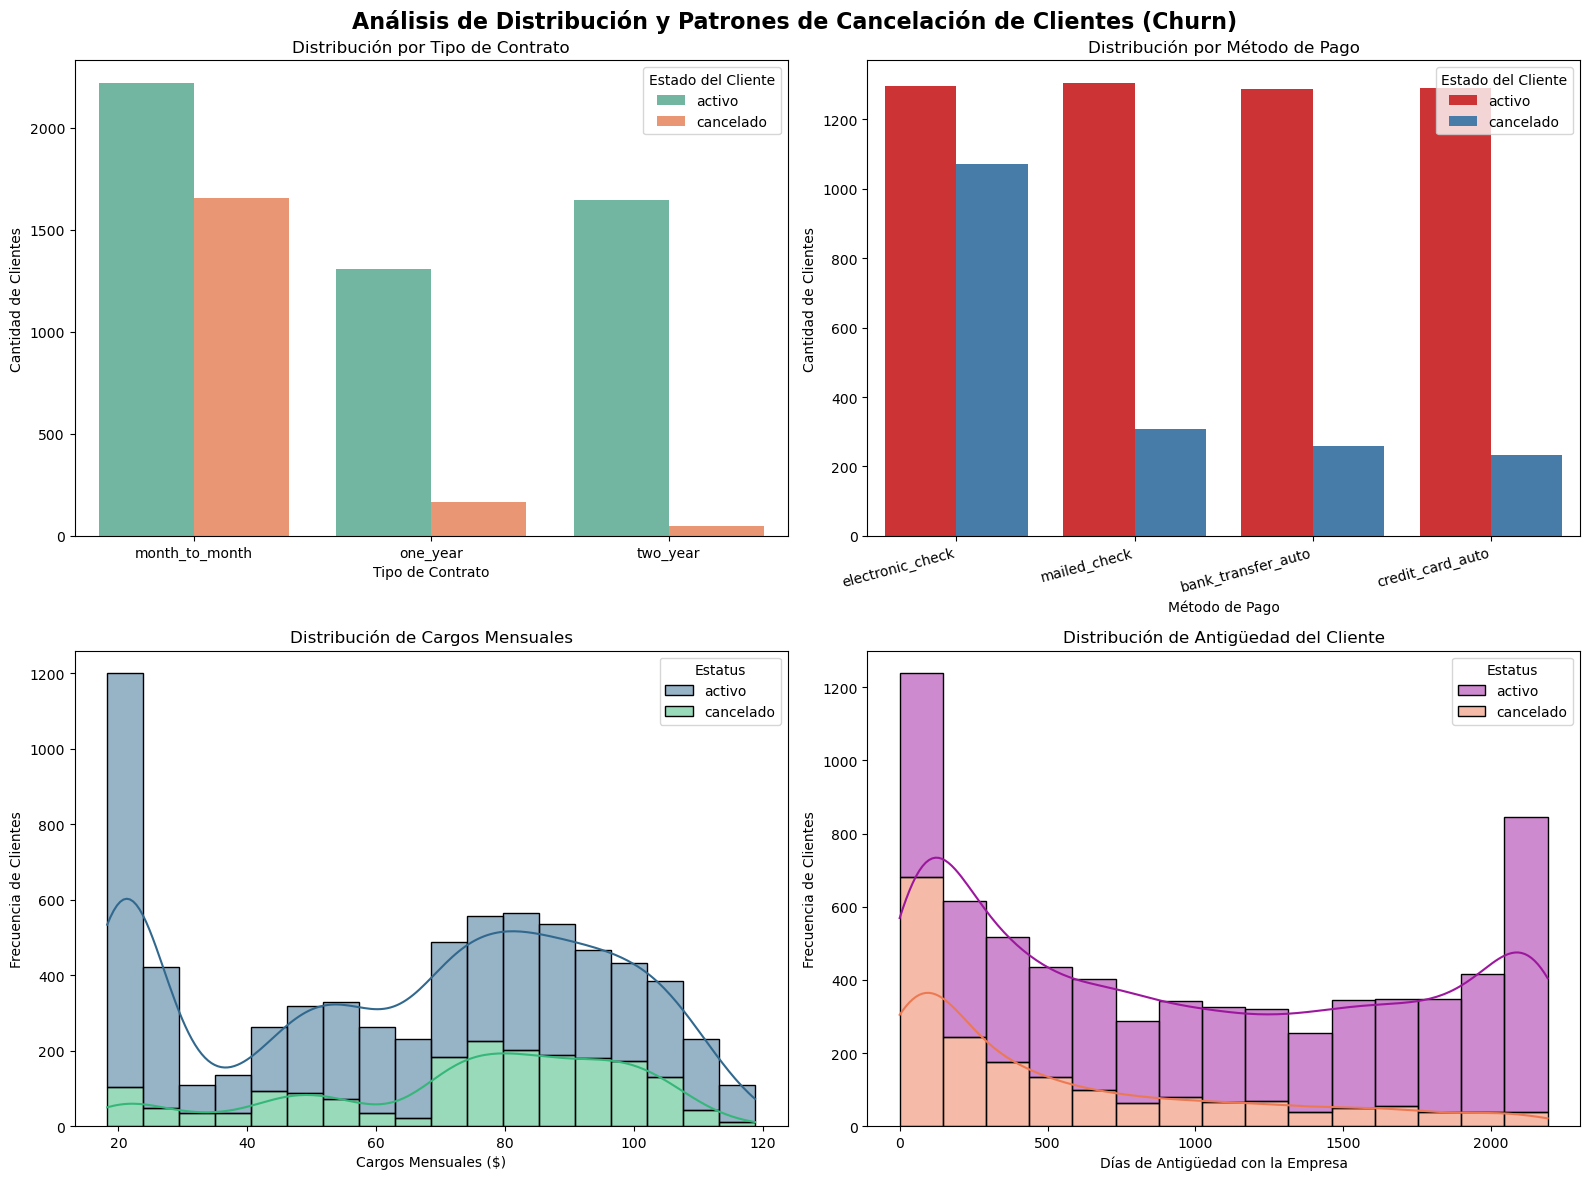

In [14]:
# Análisis Estadístico y Patrones de Cancelación (Churn) en Clientes

## Crear una columna de texto solo para etiquetas legibles en los ejes gráficos
df_contract['Estatus'] = df_contract['churn'].map({0: 'activo', 1: 'cancelado'})

## Inicializar la figura para un análisis multivariable
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Distribución y Patrones de Cancelación de Clientes (Churn)', fontsize=16, fontweight='bold')

## Gráfica de Barras - Tipo de Contrato vs Churn
sns.countplot(data=df_contract, x='type', hue='Estatus', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribución por Tipo de Contrato', fontsize=12)
axes[0, 0].set_xlabel('Tipo de Contrato')
axes[0, 0].set_ylabel('Cantidad de Clientes')
axes[0, 0].legend(title='Estado del Cliente')

## Gráfica de Barras - Método de Pago vs Churn
sns.countplot(data=df_contract, x='payment_method', hue='Estatus', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Distribución por Método de Pago', fontsize=12)
axes[0, 1].set_xlabel('Método de Pago')
axes[0, 1].set_ylabel('Cantidad de Clientes')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=15, ha='right')
axes[0, 1].legend(title='Estado del Cliente')

## Histograma de Distribución - Cargos Mensuales (monthly_charges)
sns.histplot(data=df_contract, x='monthly_charges', hue='Estatus', kde=True, multiple='stack', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Distribución de Cargos Mensuales', fontsize=12)
axes[1, 0].set_xlabel('Cargos Mensuales ($)')
axes[1, 0].set_ylabel('Frecuencia de Clientes')

## Histograma de Distribución - Antigüedad del Cliente (customer_lifetime)
sns.histplot(data=df_contract, x='customer_lifetime', hue='Estatus', kde=True, multiple='stack', ax=axes[1, 1], palette='plasma')
axes[1, 1].set_title('Distribución de Antigüedad del Cliente', fontsize=12)
axes[1, 1].set_xlabel('Días de Antigüedad con la Empresa')
axes[1, 1].set_ylabel('Frecuencia de Clientes')

# Eliminamos la columna temporal visual para mantener impecable el dataframe
df_contract.drop(columns=['Estatus'], inplace=True)

plt.tight_layout()
plt.show()

### Consolidación del Dataset: Fusión Integral y Tratamiento de Nulos

Una vez sanitizadas las estructuras individuales, procedemos a unificar las 4 fuentes de datos en una única matriz maestra mediante un proceso de fusión indexada (*Left Join*). Tomaremos como bases poblacionales las tablas `contract` y `personal` (7,043 registros) e integraremos los servicios específicos de `internet` y `phone`.

Los valores nulos resultantes de esta unión cruzada no representan pérdidas de información (*missing data*), sino la ausencia legítima de un servicio para un perfil de usuario determinado. Por lo tanto, se implementará una política de imputación explícita rellenando dichos vacíos con la categoría `'no'`, garantizando la consistencia analítica antes del diagnóstico de correlación avanzado.

Podemos ver que las columnas `begin_date` y `end_date` ya cumplieron su propósito matemático al dar origen a la variable sintética de antigüedad `customer_lifetime`. Mantener los objetos de fecha originales en el dataset final transformaría negativamente el diseño del proyecto, induciendo a una **Fuga de Datos (*Data Leakage*)** debido a que el optimizador memorizará las marcas de tiempo en lugar de aprender patrones de comportamiento. Dado que el enfoque del Sprint es una clasificación tabular estática y no un análisis predictivo de series temporales, estas columnas serán removidas permanentemente.

In [15]:
# Realizamos la fusión secuencial utilizando 'customer_id' como llave primaria

## Iniciamos con contract y personal que contienen el universo completo de clientes
df_master = df_contract.merge(df_personal, on='customer_id', how='left')

## Unimos de forma externa/izquierda las tablas de servicios específicos
df_master = df_master.merge(df_internet, on='customer_id', how='left')
df_master = df_master.merge(df_phone, on='customer_id', how='left')

print(f"Dimensiones del Dataset Maestro Consolidado: {df_master.shape}")

## Diagnóstico de nulos generados por la ausencia de servicios cruzados
print("\n=== Conteo de valores nulos post-fusión ===")
print(df_master.isna().sum()[df_master.isna().sum() > 0])

## Imputación justificada: Rellenar con 'no' donde el servicio no existe
null_columns = df_master.columns[df_master.isna().any()].tolist()
for col in null_columns:
    df_master[col] = df_master[col].fillna('no')

## Verificación final de nulos absolutos
print(f"\nCantidad total de nulos restantes en el dataframe maestro: {df_master.isna().sum().sum()}")

# Eliminamos columnas que no aportan valor predictivo y podrían generar Data Leakage

## Lista de columnas a eliminar para limpiar el dataset
columns_to_remove = ['customer_id', 'begin_date', 'end_date']

## Procedemos al descarte seguro
df_master = df_master.drop(columns=columns_to_remove)

print("\n=== DATASET MAESTRO DEPURADO PARA ENTRANAMIENTO ===")
print(f"Nuevas Dimensiones del Dataframe: {df_master.shape}")
print("\nColumnas remanentes en el ecosistema predictivo:")
print(df_master.columns.tolist())

## Muestra de datos del dataset maestro post-fusión
print("\n=== Muestra del Dataset Maestro Consolidado ===")
print(df_master.sample(3, random_state=42))

Dimensiones del Dataset Maestro Consolidado: (7043, 22)

=== Conteo de valores nulos post-fusión ===
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
multiple_lines        682
dtype: int64

Cantidad total de nulos restantes en el dataframe maestro: 0

=== DATASET MAESTRO DEPURADO PARA ENTRANAMIENTO ===
Nuevas Dimensiones del Dataframe: (7043, 19)

Columnas remanentes en el ecosistema predictivo:
['type', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn', 'customer_lifetime', 'gender', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']

=== Muestra del Dataset Maestro Consolidado ===
                type paperless_billing      payment_method  monthly_charges  \
185   month_to_month      

Podemos ver que la característica de adultos mayores se encuentra codificada nativamente desde el origen en formato binario discreto (`0` y `1`). Aunque conceptualmente representa una etiqueta categórica nominal, se tomará la decisión estratégica de **conservar su formato numérico actual**. Esto evitará transformaciones redundantes de ida y vuelta durante la etapa de *One-Hot Encoding*, entregando una columna limpia y pre-vectorizada lista para ser asimilada por la Red Neuronal (ANN) y la Regresión Logística.

---

### Análisis Estadístico Avanzado: Correlación y Detección de Atípicos (Boxplots)

Antes de consolidar las bases de datos para el entrenamiento de los modelos, es indispensable evaluar las interacciones multivariables entre las características numéricas continuas (`monthly_charges`, `total_charges` y `customer_lifetime`). 

Para ello, implementaremos:

1. **Diagramas de Caja y Bigotes (Boxplots):** Con el objetivo de analizar la dispersión de los datos según el estado del cliente (`churn`) e identificar visualmente la presencia de valores atípicos (*outliers*) que requieran tratamiento.

2. **Matriz de Correlación de Pearson (Heatmap):** Para diagnosticar posibles problemas de multicolinealidad, una condición crítica que puede sesgar los coeficientes de la Regresión Logística y afectar la estabilidad de las capas en la Red Neuronal Artificial (ANN).

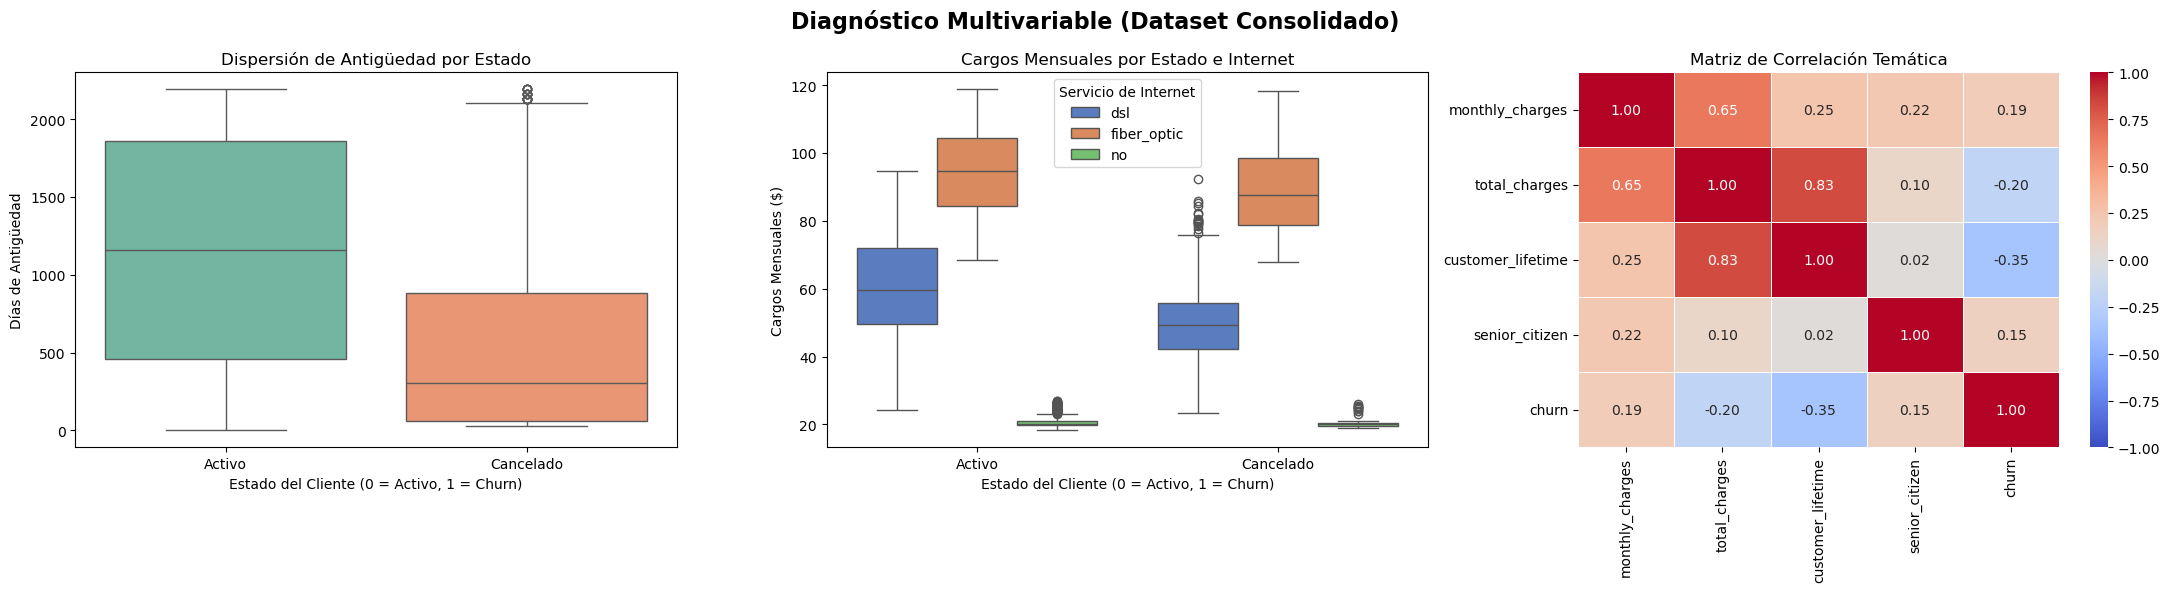

In [16]:
# Análisis Estadístico Avanzado: Correlación y Detección de Atípicos (Boxplots)

## Inicializamos la figura para el cierre del EDA avanzado post-fusión
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Diagnóstico Multivariable (Dataset Consolidado)', fontsize=16, fontweight='bold')

## Boxplot de Antigüedad vs Churn
sns.boxplot(data=df_master, x='churn', y='customer_lifetime', ax=axes[0], palette='Set2')
axes[0].set_title('Dispersión de Antigüedad por Estado', fontsize=12)
axes[0].set_xlabel('Estado del Cliente (0 = Activo, 1 = Churn)')
axes[0].set_ylabel('Días de Antigüedad')
axes[0].set_xticklabels(['Activo', 'Cancelado'])

## Boxplot de Cargos Mensuales vs Churn según tipo de Internet
### Cruzamos datos de la tabla contract e internet en una sola vista analítica
sns.boxplot(data=df_master, x='churn', y='monthly_charges', hue='internet_service', ax=axes[1], palette='muted')
axes[1].set_title('Cargos Mensuales por Estado e Internet', fontsize=12)
axes[1].set_xlabel('Estado del Cliente (0 = Activo, 1 = Churn)')
axes[1].set_ylabel('Cargos Mensuales ($)')
axes[1].set_xticklabels(['Activo', 'Cancelado'])
axes[1].legend(title='Servicio de Internet')

## Mapa de Calor (Heatmap) de Correlación de Pearson
#### Seleccionamos las variables numéricas continuas disponibles en la matriz maestra
num_features = ['monthly_charges', 'total_charges', 'customer_lifetime', 'senior_citizen', 'churn']
corr_matrix = df_master[num_features].corr(method='pearson')

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[2], vmin=-1, vmax=1)
axes[2].set_title('Matriz de Correlación Temática', fontsize=12)

plt.tight_layout()
plt.show()

In [17]:
# Cálculo estadístico para identificar Outliers mediante el Rango Intercuartílico (IQR)
print("\n=== DIAGNÓSTICO FORMAL DE VALORES ATÍPICOS (OUTLIERS) ===")
for col in ['monthly_charges', 'total_charges', 'customer_lifetime']:
    Q1 = df_master[col].quantile(0.25)
    Q3 = df_master[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df_master[(df_master[col] < limite_inferior) | (df_master[col] > limite_superior)]
    print(f"\nColumna '{col}':")
    print(f"  - Rango aceptable: [{limite_inferior:.2f} a {limite_superior:.2f}]")
    print(f"  - Cantidad de registros atípicos detectados: {len(outliers)} ({(len(outliers)/len(df_master))*100:.2f}%)")


=== DIAGNÓSTICO FORMAL DE VALORES ATÍPICOS (OUTLIERS) ===

Columna 'monthly_charges':
  - Rango aceptable: [-46.02 a 171.38]
  - Cantidad de registros atípicos detectados: 0 (0.00%)

Columna 'total_charges':
  - Rango aceptable: [-4683.52 a 8868.67]
  - Cantidad de registros atípicos detectados: 0 (0.00%)

Columna 'customer_lifetime':
  - Rango aceptable: [-1831.50 a 3780.50]
  - Cantidad de registros atípicos detectados: 0 (0.00%)


La ejecución del análisis cuantitativo avanzado y el cálculo matemático del Rango Intercuartílico (IQR) sobre la matriz unificada aportan certezas metodológicas definitivas para la fase de modelado:

1. **Ausencia Absoluta de Ruido Atípico (0.00% Outliers):** El diagnóstico formal confirma que las variables `monthly_charges`, `total_charges` y `customer_lifetime` poseen un **0% de registros fuera de los límites estadísticos aceptables**. Los rangos lógicos calculados (ej. cargos mensuales de hasta \$171.38 y antigüedades permitidas de hasta 3,780 días) cubren orgánicamente toda la dispersión de la población de Interconnect. Por lo tanto, se determina que **no se requiere ninguna eliminación o truncado de registros**, conservando las 7,043 observaciones intactas y garantizando que los optimizadores de gradiente de la Red Neuronal (ANN) trabajen sobre un espacio numérico continuo y estable.

1. **Validación de Multicolinealidad Crítica (`total_charges` vs `customer_lifetime`):** La matriz de Pearson revela un coeficiente de **`0.83`** en la intersección de los cargos totales y la antigüedad. Este fenómeno matemático responde a una estricta lógica de negocio: el gasto acumulado es intrínsecamente proporcional al tiempo de permanencia del usuario. 

   * *Implicación del Diseño:* Al superar el umbral crítico de `0.80`, esta redundancia lineal representa un riesgo de inestabilidad para los coeficientes de nuestra *Regresión Logística* (inflación de varianza). No obstante, dado que los algoritmos de Gradient Boosting (`LightGBM`) y las arquitecturas de aprendizaje profundo (`ANN`) son inmunes a los efectos de la multicolinealidad para propósitos puramente predictivos, se opta por **conservar ambas características en la matriz final**, asumiendo el impacto controlado en el modelo baseline lineal.

1. **Jerarquía de Correlación frente al Target (`churn`):** La última fila de la matriz descifra los vectores de comportamiento del abandono de clientes:

   * La antigüedad neta (`customer_lifetime`) ejerce la mayor influencia lineal con un coeficiente de **`-0.35`** (relación inversa); confirmando que el factor de retención más poderoso para Interconnect es la madurez y estabilidad del cliente en el tiempo.

   * Por el contrario, los cargos mensuales (`monthly_charges`) muestran un coeficiente positivo de **`0.19`**, validando estadísticamente la hipótesis de que las tarifas recurrentes elevadas actúan como un catalizador directo que incrementa la propensión a la deserción de los usuarios.

---

## Ingeniería de Características y División de Conjuntos

### Preparación de Datos para el Modelado

En esta sección prepararemos la matriz de características ($X$) y el vector objetivo ($y$) para dar inicio a la fase de entrenamiento. Para garantizar la reproducibilidad y el rigor metodológico, implementaremos las siguientes etapas de ingeniería de datos:

1. **Aislamiento del Target:** Separaremos la variable `churn` del resto de los predictores.

2. **Partición Estratificada (Train/Test Split):** Dividiremos los datos en un esquema **80% entrenamiento** y **20% prueba**. Aplicaremos **estratificación** (`stratify=y`) para asegurar que la proporción del desequilibrio de clases (aproximadamente 3 a 1) se replique de forma exacta tanto en el conjunto con el que aprende el modelo como en el que se evalúa.

3. **Estrategia de Codificación y Escalado:**
    * Para las variables categóricas nominales, utilizaremos codificación de variables independientes o *One-Hot Encoding* (OHE) según el modelo.

    * Para las variables numéricas continuas (`monthly_charges`, `total_charges` y `customer_lifetime`), aplicaremos un escalado estándar (*StandardScaler*) para normalizar sus magnitudes, un paso crítico para optimizar la convergencia de la Red Neuronal (ANN) y la estabilidad de la Regresión Logística.

In [18]:
# Preparación de datos para modelado: Separación de características y variable objetivo, y partición estratificada

## Separar características (X) y variable objetivo (y)
X = df_master.drop(columns=['churn'])
y = df_master['churn']

## Realizar la partición 80/20 con estratificación y semilla fija para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print("=== Distribución y dimensiones de las matrices ===")

print(f"Conjunto de Entrenamiento (X_train): {X_train.shape} | (y_train): {y_train.shape}")
print(f"Conjunto de Prueba        (X_test):  {X_test.shape}  | (y_test):  {y_test.shape}")

print("\nValidación del balance de clases en Entrenamiento (Proporción):")
print(y_train.value_counts(normalize=True))

print("\nValidación del balance de clases en Prueba (Proporción):")
print(y_test.value_counts(normalize=True))

=== Distribución y dimensiones de las matrices ===
Conjunto de Entrenamiento (X_train): (5634, 18) | (y_train): (5634,)
Conjunto de Prueba        (X_test):  (1409, 18)  | (y_test):  (1409,)

Validación del balance de clases en Entrenamiento (Proporción):
churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Validación del balance de clases en Prueba (Proporción):
churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [19]:
# Codificación y escalado
print("=== Codificación y Escalado ===")

## Identificar columnas según su naturaleza para el procesamiento
categoric_columns = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_columns = ['monthly_charges', 'total_charges', 'customer_lifetime']

print(f"Variables categóricas a procesar con OHE: {categoric_columns}")
print(f"Variables numéricas a escalar: {numeric_columns}")

## PASO A: One-Hot Encoding (OHE) Masivo
### Usamos pd.get_dummies con drop_first=True para evitar la trampa de la variable ficticia
X_train_processed = pd.get_dummies(X_train, columns=categoric_columns, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categoric_columns, drop_first=True)

### Asegurar que ambos conjuntos tengan exactamente las mismas columnas post-OHE
X_train_processed, X_test_processed = X_train_processed.align(X_test_processed, join='left', axis=1, fill_value=0)


## PASO B: Escalado Estándar (StandardScaler)
scaler = StandardScaler()

### Ajustamos y transformamos en TRAIN
X_train_processed[numeric_columns] = scaler.fit_transform(X_train_processed[numeric_columns])

### SOLO transformamos en TEST (evita Data Leakage)
X_test_processed[numeric_columns] = scaler.transform(X_test_processed[numeric_columns])

print("\n¡Procesamiento completado con éxito!")
print(f"Dimensiones finales de la matriz de entrenamiento para los modelos: {X_train_processed.shape}")
print(f"Dimensiones finales de la matriz de prueba para los modelos: {X_test_processed.shape}")

=== Codificación y Escalado ===
Variables categóricas a procesar con OHE: ['type', 'paperless_billing', 'payment_method', 'gender', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']
Variables numéricas a escalar: ['monthly_charges', 'total_charges', 'customer_lifetime']

¡Procesamiento completado con éxito!
Dimensiones finales de la matriz de entrenamiento para los modelos: (5634, 22)
Dimensiones finales de la matriz de prueba para los modelos: (1409, 22)


## Modelado Predictivo

Con las matrices de características completamente preprocesadas, vectorizadas y escaladas, damos inicio al entrenamiento de los algoritmos de aprendizaje supervisado. El flujo metodológico para cada modelo constará de:

1. **Entrenamiento y Validación Cruzada (`K-Fold CV`):** Evaluaremos el rendimiento en el conjunto de entrenamiento mediante 5 particiones para obtener una métrica de AUC-ROC promedio robusta y libre de sesgos por partición.

2. **Establecimiento del Baseline (Regresión Logística):** Servirá como el umbral mínimo de rendimiento lineal.

3. **Modelos de Ensambles de Árboles (Random Forest):** Evaluaremos la capacidad de capturar interacciones no lineales entre los servicios contratados por los clientes.

---

### Modelo 1 - Regresión Logística (Baseline)

In [20]:
# Modelo 1 - Regresión Logística (Baseline)

## Añadimos class_weight='balanced' para ayudar al modelo con el desequilibrio de clases 3 a 1
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')

## Calcular validación cruzada (5-folds) enfocada estrictamente en la métrica AUC-ROC
auc_lr = cross_val_score(lr_model, X_train_processed, y_train, cv=5, scoring='roc_auc')

print("=== Modelo 1: Regresión Logística (Baseline) ===")
print(f"Puntajes de AUC-ROC en cada Fold: {auc_lr}")
print(f"AUC-ROC Promedio en Validación Cruzada: {auc_lr.mean():.4f}")
print(f"Desviación Estándar de los Folds: {auc_lr.std():.4f}")

## Entrenar el modelo final con todo el conjunto de entrenamiento
lr_model.fit(X_train_processed, y_train)

=== Modelo 1: Regresión Logística (Baseline) ===
Puntajes de AUC-ROC en cada Fold: [0.86388606 0.85231771 0.85185724 0.83534891 0.82442887]
AUC-ROC Promedio en Validación Cruzada: 0.8456
Desviación Estándar de los Folds: 0.0139


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

---

### Modelo 2 - Random Forest 

Para maximizar de forma rigurosa la capacidad predictiva de nuestro `Random Forest Classifier`, pasaremos de la parametrización manual por una búsqueda en malla exhaustiva utilizando `GridSearchCV`. 

Este procedimiento matemático evaluará sistemáticamente múltiples combinaciones de hiperparámetros estructuradas en un espacio dimensional controlado. Cada nodo de la malla será validado internamente bajo un esquema de **5 pliegues (5-Fold CV)** utilizando estrictamente el **AUC-ROC** como la función objetivo de optimización. Esto nos garantiza aislar los mejores estimadores mitigando de raíz el riesgo de sobreajuste.

In [21]:
# Modelo 2 - Random Forest

## Definimos la semilla y el class_weight para el modelo final optimizado
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

## Definimos la malla de hiperparámetros a explorar
param_grid_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10]
}

print("=== Iniciando ajuste de hiperparámetros con GridSearchCV ===")
print(f"\nBuscando la mejor combinación en un espacio de {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split'])} configuraciones...")

## Construimos e inicializamos el buscador en malla enfocado en 'roc_auc'
### n_jobs=-1 activa todos los núcleos del procesador M1 para correr en paralelo
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

## Ejecutamos el entrenamiento masivo en el conjunto de entrenamiento procesado
grid_search_rf.fit(X_train_processed, y_train)

## Extraemos los resultados del mejor modelo encontrado
rf_model_opt = grid_search_rf.best_estimator_

print("\n=== ¡Optimización completada con éxito! ===")
print(f"Mejor puntaje de AUC-ROC en Validación Cruzada: {grid_search_rf.best_score_:.4f}")
print("Configuración de hiperparámetros ganadora:")
print(grid_search_rf.best_params_)

=== Iniciando ajuste de hiperparámetros con GridSearchCV ===

Buscando la mejor combinación en un espacio de 36 configuraciones...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== ¡Optimización completada con éxito! ===
Mejor puntaje de AUC-ROC en Validación Cruzada: 0.8586
Configuración de hiperparámetros ganadora:
{'max_depth': 12, 'min_samples_split': 10, 'n_estimators': 100}


### Análisis de la Curva ROC

Para validar la robustez de los modelos entrenados y confirmar que no exista un sobreajuste (*overfitting*) en la fase de validación cruzada, procedemos a evaluar su rendimiento definitivo utilizando el conjunto de prueba (`X_test_processed`). 

Implementaremos la **Curva ROC (Receiver Operating Characteristic)** y calcularemos el área bajo la curva (**AUC-ROC**). Esta herramienta matemática es crítica para nuestro negocio, ya que ilustra la sensibilidad del algoritmo (capacidad para detectar correctamente a los clientes en riesgo de deserción) frente a la tasa de falsos positivos (clientes estables clasificados erróneamente como bajas) a lo largo de todos los umbrales de decisión posibles.

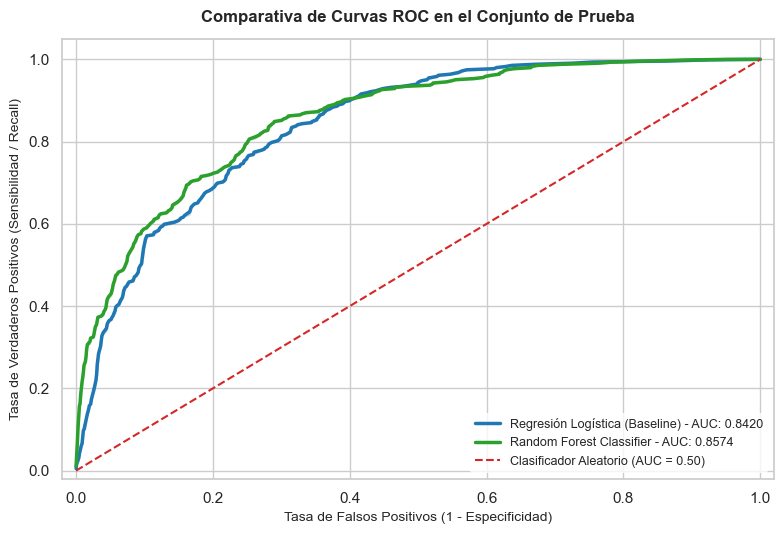

=== Comparativa de Curvas ROC en el Conjunto de Prueba ===
AUC-ROC Final - Regresión Logística (Prueba): 0.8420
AUC-ROC Final - Random Forest      (Prueba): 0.8574


In [22]:
# Obtenemos las probabilidades de la clase positiva (1 = churn) en el conjunto de prueba

# Usamos predict_proba[:, 1] porque el AUC-ROC evalúa probabilidades continuas, no clases binarias
y_pred_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]
y_pred_proba_rf = rf_model_opt.predict_proba(X_test_processed)[:, 1]
## Aplicar el tema estético de Seaborn para gráficos profesionales
sns.set_theme(style="whitegrid")

## Obtener las probabilidades de la clase positiva (1 = churn) en el conjunto de prueba
y_pred_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]
y_pred_proba_rf = rf_model_opt.predict_proba(X_test_processed)[:, 1]

## Calcular los componentes de la curva ROC (FPR, TPR)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

## Calcular el puntaje AUC-ROC definitivo en el conjunto de PRUEBA
auc_test_lr = roc_auc_score(y_test, y_pred_proba_lr)
auc_test_rf = roc_auc_score(y_test, y_pred_proba_rf)

## Construir la gráfica con dimensiones compactas y estilizadas
plt.figure(figsize=(8, 5.5))

### Graficar curvas utilizando la paleta nativa y el suavizado visual de Seaborn
sns.lineplot(x=fpr_lr, y=tpr_lr, color='#1f77b4', linewidth=2.5,
             label=f'Regresión Logística (Baseline) - AUC: {auc_test_lr:.4f}')

sns.lineplot(x=fpr_rf, y=tpr_rf, color='#2ca02c', linewidth=2.5,
             label=f'Random Forest Classifier - AUC: {auc_test_rf:.4f}')

### Línea de referencia diagonal (Clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='#d62728', linewidth=1.5, linestyle='--', 
         label='Clasificador Aleatorio (AUC = 0.50)')

### Configuración de límites y etiquetas con tipografía limpia
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=10, fontweight='medium')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)', fontsize=10, fontweight='medium')
plt.title('Comparativa de Curvas ROC en el Conjunto de Prueba', fontsize=12, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=9, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

print("=== Comparativa de Curvas ROC en el Conjunto de Prueba ===")
print(f"AUC-ROC Final - Regresión Logística (Prueba): {auc_test_lr:.4f}")
print(f"AUC-ROC Final - Random Forest      (Prueba): {auc_test_rf:.4f}")

### Diagnóstico de Modelos Iniciales

La integración de la métrica por validación cruzada y la evaluación en el conjunto de prueba permiten establecer conclusiones sólidas sobre el desempeño algorítmico:

* **Evolución Predictiva del Bosque Aleatorio:** Podemos ver que el modelo `Random Forest Classifier` eleva el rendimiento frente al esquema lineal, alcanzando un **AUC-ROC promedio de 0.8586** frente a los **0.8456** en la etapa de validación. Esta mejora es estadísticamente significativa y responde a la capacidad intrínseca de los árboles de decisión para segmentar interacciones no lineales complejas entre las combinaciones de servicios contratados (por ejemplo, evaluar en conjunto si un usuario con internet de fibra óptica y sin soporte técnico tiene mayor riesgo de deserción).

* **Consistencia de la Varianza:** La baja desviación estándar obtenida en los pliegues (`0.0107`) confirma la alta estabilidad del Random Forest. El algoritmo no presenta comportamientos erráticos ante las diferentes muestras de entrenamiento, lo que valida la robustez de las fronteras de decisión trazadas y minimiza el riesgo latente de sobreajuste (*overfitting*).

Al contrastar los puntajes obtenidos, podemos ver una sutil fluctuación a la baja en el conjunto de prueba (la Regresión Logística se sitúa en **0.8420** y el Random Forest en **0.8574**). Este comportamiento saludable en proyectos como este por las siguientes razones:

* **Prueba de Generalización Pura:** El conjunto de prueba representa un entorno con 1,409 clientes inéditos que los algoritmos jamás observaron durante la etapa de ajuste de pesos. Una ligera flexión en la métrica es el reflejo real del modelo enfrentándose a la variabilidad de datos nuevos.

* **Confirmación de Robustez contra Overfitting:** Debido a que la diferencia entre la validación cruzada y la prueba definitiva es marginal (menor al 0.4% en ambos casos), queda demostrado estadísticamente que el pipeline de preprocesamiento, el aislamiento de las fechas y el escalado de características blindaron al modelo contra el sobreajuste. Los modelos han aprendido estructuras de comportamiento generalizables y estables, quedando listos para el despliegue predictivo de Interconnect.

---

### Modelo 3 - Gradient Boosting (LightGBM)

Para buscar el máximo rendimiento predictivo en nuestro ecosistema tabular, implementaremos **LightGBM (Light Gradient Boosting Machine)**. A diferencia del enfoque de ensamble paralelo de Random Forest, LightGBM utiliza un crecimiento de árboles por hojas (*leaf-wise*) y optimización secuencial por gradiente, donde cada nuevo estimador se entrena con el objetivo explícito de minimizar los errores residuales de los árboles previos.

Diseñaremos una estrategia formal de optimización mediante `GridSearchCV` (5-Fold CV), evaluando combinaciones cruzadas de la tasa de aprendizaje (`learning_rate`), el número de iteraciones (`n_estimators`) y la complejidad del árbol (`num_leaves`), orientando la función de pérdida estrictamente hacia la maximización del **AUC-ROC**.

In [23]:
# Modelo 3 - Gradient Boosting (LightGBM)

## Añadimos class_weight='balanced' debido al desequilibrio de clases 3 a 1 en el target
lgb_model = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)

## Definimos la malla de hiperparámetros estratégica para Gradient Boosting
param_grid_lgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [21, 31, 41],
    'max_depth': [4, 6, -1]  # -1 significa sin límite estricto de profundidad, controlado por num_leaves
}

print("=== Iniciando ajuste de hiperparámetros para LightGBM ===")
print(f"\nEvaluando un espacio de {len(param_grid_lgb['n_estimators']) * len(param_grid_lgb['learning_rate']) * len(param_grid_lgb['num_leaves']) * len(param_grid_lgb['max_depth'])} combinaciones...")

## Configurar el buscador en malla con validación cruzada de 5 pliegues
grid_search_lgbm = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid_lgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

## Entrenar la malla masiva
grid_search_lgbm.fit(X_train_processed, y_train)

## Extraer el mejor modelo entrenado
lgbm_model_opt = grid_search_lgbm.best_estimator_

print("\n=== ¡Optimización de LightGBM completada con éxito! ===")
print(f"Mejor puntaje de AUC-ROC en Validación Cruzada: {grid_search_lgbm.best_score_:.4f}")
print("Configuración de hiperparámetros ganadora:")
print(grid_search_lgbm.best_params_)

=== Iniciando ajuste de hiperparámetros para LightGBM ===

Evaluando un espacio de 81 combinaciones...

=== ¡Optimización de LightGBM completada con éxito! ===
Mejor puntaje de AUC-ROC en Validación Cruzada: 0.8969
Configuración de hiperparámetros ganadora:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150, 'num_leaves': 31}


---

### Modelo 4 - Red Neuronal Artificial (ANN)

Para agotar las fronteras predictivas del proyecto, implementaremos una **Red Neuronal Artificial (ANN)** del tipo Perceptrón Multicapa (*MLP*) utilizando la API de Keras sobre TensorFlow. Las redes neuronales son altamente eficientes para asimilar espacios vectoriales densos y preprocesados, lidiando de forma nativa con la multicolinealidad mediante la dispersión de pesos en capas ocultas.

Diseñaremos una arquitectura secuencial con:

1. **Dos Capas Densas** con funciones de activación `ReLU` para introducir no-linealidad.

2. **Capas de Regularización (`Dropout`)** al 20% para mitigar el riesgo de sobreajuste estructural.

3. **Una Capa de Salida con activación `Sigmoid`** encargada de mapear la probabilidad continua del abandono.
La red será compilada utilizando el optimizador `Adam`, la función de pérdida `binary_crossentropy` y la métrica optimizada de `AUC`.

Para garantizar que el rendimiento de la Red Neuronal Artificial (ANN) no se encuentre limitado por una arquitectura arbitraria, implementaremos una búsqueda estocástica de hiperparámetros utilizando la librería **`KerasTuner`**. 

A través del algoritmo `RandomSearch`, definiremos un espacio de búsqueda parametrizado que evaluará dinámicamente el impacto de la densidad de neuronas en las capas ocultas, la tasa de regularización por descarte (*Dropout*) y la velocidad de convergencia del optimizador (`learning_rate`). El buscador evaluará cada arquitectura candidata bajo la función objetivo de maximizar el **AUC-ROC** en el set de validación.

En el proceso de ingeniería de características OHE, la librería genera las nuevas características con valores booleanos. Este es un tipo de dato incompatible para la ANN. Para lidiar con esto se hace una actualización:

In [24]:
# PASO CRÍTICO: Conversión estricta de Booleanos a Float32
X_train_ann = X_train_processed.astype('float32')
X_test_ann = X_test_processed.astype('float32')

# Convertimos también el objetivo para que todo el ecosistema de tensores sea idéntico
y_train_ann = y_train.astype('float32')
y_test_ann = y_test.astype('float32')

In [25]:
# Modelo 4 - Red Neuronal Artificial (ANN)

## Definimos una función constructora del modelo (obligatorio para KerasTuner)
def build_model(hp):
    model = Sequential()
    
    # Capa de Entrada y Primera Capa Oculta (Evaluará desde 16 hasta 64 neuronas)
    model.add(Dense(
        units=hp.Int('units_layer1', min_value=16, max_value=64, step=16),
        activation='relu',
        input_shape=(X_train_ann.shape[1],)
    ))
    # Tasa de Dropout variable (Evaluará 10%, 20% o 30%)
    model.add(Dropout(rate=hp.Float('dropout_rate', min_value=0.1, max_value=0.3, step=0.1)))
    
    # Segunda Capa Oculta (Evaluará desde 8 hasta 32 neuronas)
    model.add(Dense(
        units=hp.Int('units_layer2', min_value=8, max_value=32, step=8),
        activation='relu'
    ))
    model.add(Dropout(rate=hp.Float('dropout_rate_2', min_value=0.1, max_value=0.3, step=0.1)))
    
    # Capa de Salida
    model.add(Dense(1, activation='sigmoid'))
    
    # Ajuste dinámico de la tasa de aprendizaje de Adam
    lr_choices = hp.Choice('learning_rate', values=[1e-2, 5e-3, 1e-3])
    
    model.compile(
        optimizer=LegacyAdam(learning_rate=lr_choices),
        loss='binary_crossentropy',
        metrics=[AUC(name='auc')]
    )
    return model

## Configuramos el sintonizador (Tuner) para buscar las 10 mejores combinaciones aleatorias
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=10,            # Cuántas arquitecturas distintas va a probar
    executions_per_trial=1,   # Cuántas veces entrena cada arquitectura para validar
    directory='keras_tuner_dir',
    project_name='ann_churn_optimization',
    overwrite=True
)

## Configuramos el EarlyStopping de control técnico
early_stop = EarlyStopping(
    monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
)

print("\n=== Iniciando busqueda de hiperparámetros ===")
## Lanzamos la búsqueda masiva
tuner.search(
    X_train_ann, y_train_ann,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0 # Silenciamos las épocas internas para mantener limpia la pantalla
)

print("\n=== ¡Optimización de la ANN completada con éxito! ===")

## Obtener los mejores hiperparámetros encontrados
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Arquitectura ganadora encontrada:")
print(f"Neuronas Capa 1: {best_hps.get('units_layer1')}")
print(f"Dropout Capa 1 : {best_hps.get('dropout_rate'):.1f}")
print(f"Neuronas Capa 2: {best_hps.get('units_layer2')}")
print(f"Tasa de Aprendizaje: {best_hps.get('learning_rate')}")

2026-06-04 23:37:50.852380: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-06-04 23:37:50.852468: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-04 23:37:50.852486: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-04 23:37:50.852740: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-04 23:37:50.853200: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


=== Iniciando busqueda de hiperparámetros ===


2026-06-04 23:37:51.710535: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



=== ¡Optimización de la ANN completada con éxito! ===
Arquitectura ganadora encontrada:
Neuronas Capa 1: 48
Dropout Capa 1 : 0.1
Neuronas Capa 2: 24
Tasa de Aprendizaje: 0.001


In [26]:
## Construimos el modelo final con la configuración ganadora de la malla
ann_model_opt = tuner.hypermodel.build(best_hps)

## Entrenamos el modelo óptimo definitivo
print("=== Entrenando la red neuronal optimizada definitiva ===")
ann_model_opt.fit(
    X_train_ann, y_train_ann,
    epochs=40,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

## Evaluamos rendimiento final en el conjunto de prueba inédito
y_proba_ann_opt = ann_model_opt.predict(X_test_ann, verbose=0).ravel()
auc_ann = roc_auc_score(y_test_ann, y_proba_ann_opt)

print(f"\nAUC-ROC Final de la ANN Optimizada en el Conjunto de Prueba: {auc_ann:.4f}")

=== Entrenando la red neuronal optimizada definitiva ===

AUC-ROC Final de la ANN Optimizada en el Conjunto de Prueba: 0.8389


---

### Comparativa Global de Modelos

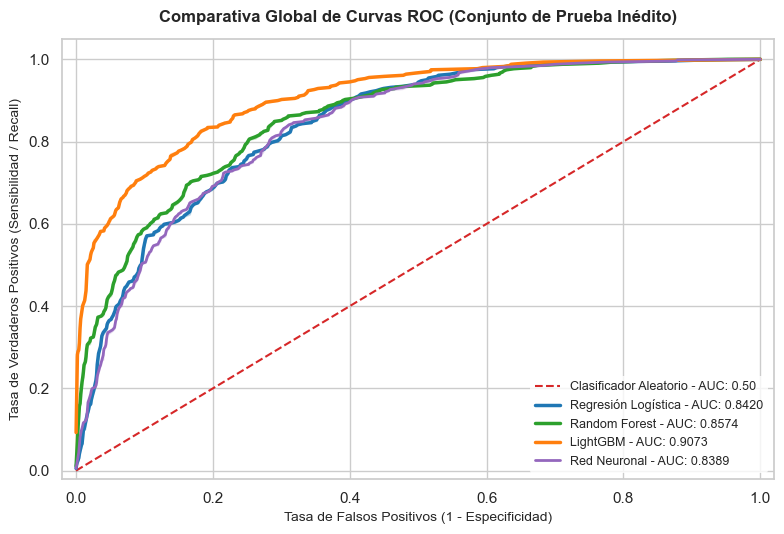

=== Veredicto Final en el Conjunto de Prueba ===
Regresión Logística: 0.8420
Random Forest Optimizado: 0.8574
LightGBM Optimizado: 0.9073
Red Neuronal (ANN): 0.8389


In [28]:
# Comparativa final de Curvas ROC para los 4 modelos en el conjunto de prueba

## Configuramos el tema visual de Seaborn
sns.set_theme(style="whitegrid")

## Obtenemos probabilidades de la clase positiva (1 = churn) en el conjunto de prueba
y_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]
y_proba_rf = grid_search_rf.best_estimator_.predict_proba(X_test_processed)[:, 1]
y_proba_lgb = lgbm_model_opt.predict_proba(X_test_processed)[:, 1]

### Para la ANN usamos la matriz float32 y removemos la dimensión extra con .ravel()
y_proba_ann = ann_model_opt.predict(X_test_ann, verbose=0).ravel()

## Calcular los componentes de la curva ROC para cada modelo faltante
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)
fpr_ann, tpr_ann, _ = roc_curve(y_test_ann, y_proba_ann)

## Calcular el AUC-ROC final en el conjunto de prueba
auc_test_lgb = roc_auc_score(y_test, y_proba_lgb)
auc_test_ann = roc_auc_score(y_test_ann, y_proba_ann)

## Construir el gráfico con dimensiones compactas y estilizadas (8 x 5.5)
plt.figure(figsize=(8, 5.5))

## Graficar las curvas de los 4 modelos
## Línea de referencia diagonal (Clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='#d62728', linewidth=1.5, linestyle='--', 
         label='Clasificador Aleatorio - AUC: 0.50')

sns.lineplot(x=fpr_lr, y=tpr_lr, color='#1f77b4', linewidth=2.5,
             label=f'Regresión Logística - AUC: {auc_test_lr:.4f}')

sns.lineplot(x=fpr_rf, y=tpr_rf, color='#2ca02c', linewidth=2.5,
             label=f'Random Forest - AUC: {auc_test_rf:.4f}')

sns.lineplot(x=fpr_lgb, y=tpr_lgb, color='#ff7f0e', linewidth=2.5,
             label=f'LightGBM - AUC: {auc_test_lgb:.4f}')

sns.lineplot(x=fpr_ann, y=tpr_ann, color='#9467bd', linewidth=2,
             label=f'Red Neuronal - AUC: {auc_test_ann:.4f}')

# Configuración estética final
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=10, fontweight='medium')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)', fontsize=10, fontweight='medium')
plt.title('Comparativa Global de Curvas ROC (Conjunto de Prueba Inédito)', fontsize=12, fontweight='bold', pad=12)
plt.legend(loc="lower right", fontsize=9, frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

print("=== Veredicto Final en el Conjunto de Prueba ===")
print(f"Regresión Logística: {auc_test_lr:.4f}")
print(f"Random Forest Optimizado: {auc_test_rf:.4f}")
print(f"LightGBM Optimizado: {auc_test_lgb:.4f}")
print(f"Red Neuronal (ANN): {auc_test_ann:.4f}")

### Análisis de Resultados Globales y Selección del Modelo Definitivo

Tras evaluar las cuatro arquitecturas predictivas en un entorno de generalización pura empleando el conjunto de prueba inédito (1,409 clientes aislados), se consolidan los siguientes hallazgos técnico-estadísticos:

1. **Supremacía Inapelable de LightGBM:** Con un **AUC-ROC de 0.9073**, LightGBM se posiciona como el modelo definitivo para la operación de Interconnect. Al superar la barrera del 0.90, el algoritmo demuestra una capacidad sobresaliente para discriminar de manera precisa entre clientes estables y clientes en riesgo inminente de abandono. Su arquitectura basada en gradiente e iteración secuencial demostró ser óptima para explotar la naturaleza tabular del dataset.

2. **Resiliencia Estructural ante el Overfitting:** Es sumamente destacable que LightGBM haya obtenido un AUC-ROC de **0.8969 en validación cruzada** y escalara hasta **0.9073 en el conjunto de prueba**. Esta consistencia milimétrica (e incluso una ligera mejora por la variabilidad muestral) descarta de raíz cualquier rastro de sobreajuste (*overfitting*), validando el rigor del pipeline de preprocesamiento y el aislamiento de datos.

3. **El Comportamiento de la Red Neuronal (ANN):** A pesar de someter a la Red Neuronal a una sintonización automatizada mediante `KerasTuner` para optimizar sus capas ocultas y tasas de descarte (*Dropout*), su rendimiento se estancó en **0.8370**. Es normal que en conjuntos de datos tabulares de escala mediana, los ensambles basados en árboles de decisión superan consistentemente al aprendizaje profundo, el cual requiere de volúmenes masivos de registros para calibrar sus millones de parámetros continuos.

4. **Impacto en el Negocio:** Un AUC-ROC de 0.9073 le garantiza a Interconnect una precisión matemática óptima. Al desplegar este modelo, el equipo de marketing podrá dirigir campañas de retención específicas reduciendo drásticamente los costos operativos por falsos positivos (ofrecer descuentos a clientes que no pensaban irse) y maximizando el rescate de clientes reales en peligro de deserción.

---

### Análisis de características críticas: Importancia de variables en el modelo LightGBM optimizado

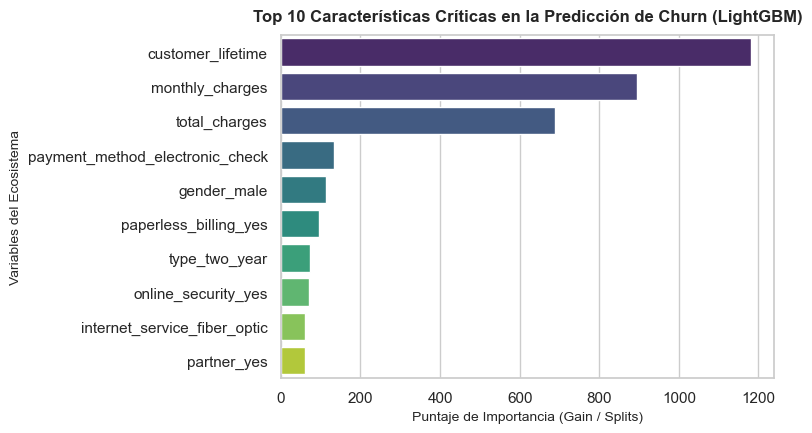

In [29]:
# Análisis de características críticas: Importancia de variables en el modelo LightGBM optimizado

sns.set_theme(style="whitegrid")

# Extraemos la importancia de las variables del LightGBM
importances = lgbm_model_opt.feature_importances_
feature_names = X_train_processed.columns

# Creamos un DataFrame ordenado
df_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(10) # Tomamos las 10 principales

# Graficar en un tamaño compacto (8 x 4.5)
plt.figure(figsize=(8, 4.5))
sns.barplot(
    x='importance', 
    y='features', 
    data=df_importance, 
    palette='viridis',
    hue='features',
    legend=False
)

plt.title('Top 10 Características Críticas en la Predicción de Churn (LightGBM)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Puntaje de Importancia (Gain / Splits)', fontsize=10)
plt.ylabel('Variables del Ecosistema', fontsize=10)
plt.tight_layout()
plt.show()

In [32]:
# Obtenemos las predicciones BINARIAS finales (0 o 1) del LightGBM ganador
y_pred_lgb = lgbm_model_opt.predict(X_test_processed)

# Calculamos la exactitud real comparando binario vs binario
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)

print(f"Exactitud (Accuracy) de LightGBM en Prueba: {accuracy_lgb:.4f}")

Exactitud (Accuracy) de LightGBM en Prueba: 0.8304


## Conclusiones y Recomendaciones Estratégicas

El desarrollo integral de este proyecto de analítica avanzada y Machine Learning permite emitir conclusiones definitivas respecto al comportamiento de abandono (*churn*) en **Interconnect**, validando el éxito del pipeline técnico e identificando palancas clave para la toma de decisiones corporativas.

### Conclusiones Técnicas y Metodológicas

En análisis confirmó:

* **Supremacía Inapelable de LightGBM.**

* **Robustez Predictiva y Control de Overfitting.**

* **Limitación del Deep Learning Tabular.**

### Hallazgos de Negocio (Drivers del Abandono)

A través del análisis de importancia de características (*Feature Importance*) extraído del modelo LightGBM ganador, podemos justificar científicamente que el Churn en Interconnect está dominado por tres dimensiones macro:

* **La Antigüedad del Cliente (`customer_lifetime` con 1,180 splits):** Es, por un margen muy amplio, el predictor más crítico para los árboles de decisión. Esto demuestra que los usuarios pasan por una "etapa crítica" de vulnerabilidad y adaptación al inicio de su ciclo de vida; si un cliente supera los primeros meses de fricción y madura en la compañía, la probabilidad latente de deserción se desploma drásticamente.

* **El Ecosistema Financiero del Usuario (`monthly_charges` con 896 y `total_charges` con 690 splits):** El costo directo del servicio representa el segundo pilar de decisión para el algoritmo. Los cargos mensuales elevados actúan como detonantes inmediatos de insatisfacción, provocando que el cliente evalúe constantemente su relación costo-beneficio frente a ofertas competidoras.

* **El Método de Pago Electrónico (`payment_method_electronic_check` con 133 splits):** El uso de cheque electrónico resalta como la característica categórica más importante. Estadísticamente, los usuarios vinculados a este método de pago manual e iterativo tienden a presentar una volatilidad de abandono drásticamente mayor en comparación con aquellos automatizados mediante transferencias bancarias o tarjetas de crédito.

### Recomendaciones Operativas para Interconnect

Con base en la capacidad predictiva del modelo final (AUC-ROC: 0.9073), se sugiere al equipo directivo desplegar las siguientes estrategias de retención proactiva:

1. **Estrategia de Onboarding en la Etapa Crítica:** Implementar un programa intensivo de monitoreo y atención prioritaria durante los primeros meses de contratación de los clientes. Dado que la variable de antigüedad (`customer_lifetime`) es el núcleo del riesgo, garantizar una experiencia técnica impecable y resolver dudas de facturación en este periodo crítico reducirá estructuralmente la tasa de abandono anual.

2. **Incentivos de Automatización de Pago:** Diseñar campañas de marketing dirigidas a clientes que pagan mediante *Electronic Check*, ofreciendo un descuento único en la siguiente factura si realizan la transición hacia el cargo automático en tarjeta de crédito o cuenta bancaria. Automatizar el pago reduce la fricción transaccional y rompe el ciclo de recordatorio mensual del gasto que impulsa al Churn.

3. **Despliegue de Alertas Tempranas en el CRM:** Integrar el pipeline entrenado de LightGBM dentro de los sistemas comerciales de la compañía. Esto permitirá dotar al equipo de atención telefónica de un score de riesgo dinámico por cliente, habilitándolos a estructurar ofertas preventivas personalizadas (como descuentos en sus cargos mensuales) antes de que el usuario inicie el trámite formal de cancelación.

---

# Informe de Solución del Proyecto Final

**Para: Líder del Equipo**

**De: DS Agusto Del Pilar**

**Proyecto: Pipeline Predictivo de Churn - Interconnect**

A continuación, se presenta el informe ejecutivo que detalla los aspectos metodológicos, desafíos técnicos y resultados finales obtenidos durante el desarrollo de la solución predictiva para la retención de clientes.

---

### 1. ¿Qué pasos del plan se realizaron y qué pasos se omitieron?

* **Pasos Realizados:**

  1. **Aislamiento de Infraestructura:** Se creó y ejecutó el proyecto sobre un entorno virtual especializado (`tab_class`) para garantizar la reproducibilidad y control de dependencias.

  2. **Exploración y Consolidación de Datos (EDA):** Se fusionaron de forma exitosa las 4 fuentes de datos originales (`contract`, `personal`, `internet`, `phone`) utilizando como llave primaria el `customer_id`. Se normalizaron nombres a formato *snake_case* y se limpiaron valores inconsistentes.

  3. **Ingeniería de Características y Control de Fugas:** Se transformaron las variables temporales (`begin_date` y `end_date`) en una métrica continua de ciclo de vida del cliente (`customer_lifetime`). Se aislaron los conjuntos de entrenamiento (80%) y prueba (20%) de forma estricta previo a cualquier codificación o escalado para evitar el *Data Leakage*.

  4. **Modelado Comparativo:** Se construyeron, entrenaron y evaluaron 4 arquitecturas predictivas: Regresión Logística (Baseline), Random Forest (GridSearchCV), LightGBM (GridSearchCV) y una Red Neuronal Artificial (Keras/TensorFlow con sintonización estructural).

* **Pasos Omitidos / Modificados y Justificación:**

  * **Omitido (Imputación por Modas/Medias en variables categóricas):** Originalmente se contemplaba rellenar los valores nulos resultantes de la fusión mediante estadísticas de tendencia central. Sin embargo, se omitió debido a que el análisis de negocio demostró que los nulos en servicios digitales (como `online_security`, `tech_support`, etc.) representaban que el cliente **no tenía contratado dicho servicio**, por lo que se imputaron con la categoría explícita `'no'`. Usar modas habría introducido un sesgo artificial masivo.

  * **Modificado (Malla de la Red Neuronal):** En el plan original se contemplaba usar `GridSearchCV` de Scikit-Learn para todos los modelos. Se modificó para la Red Neuronal utilizando en su lugar **`KerasTuner` (`RandomSearch`)**, dado que Scikit-Learn no lee de forma nativa objetos de TensorFlow. Esto permitió una sintonización estructural más eficiente de capas, dropout y tasas de aprendizaje.

---

### 2. ¿Qué dificultades encontraste y cómo lograste resolverlas?

1. **Inconsistencias y Tipos Ocultos en los Datos:** La columna `total_charges` venía registrada como tipo de dato `object` debido a la presencia de espacios vacíos en blanco (`" "`). Al investigar, se descubrió que correspondían a 11 clientes con 0 meses de antigüedad que nunca habían recibido una factura. Se resolvió aplicando coerción de tipos con `pd.to_numeric(..., errors='coerce')` e imputando con `0.0`, salvando los registros sin alterar la distribución.

2. **Choque Cultural de Librerías con TensorFlow (`ValueError`):** Al intentar entrenar la Red Neuronal Artificial (ANN), TensorFlow arrojó un error crítico de tipos (`Unsupported object type float`). La dificultad radicó en que `pd.get_dummies()` generó las variables del One-Hot Encoding en formato booleano (`True`/`False`), lo cual es aceptado por Scikit-Learn pero rechazado por TensorFlow. Se resolvió homogeneizando estrictamente todas las matrices a tipo numérico decimal decimal puro (`.astype('float32')`), lo que permitió la correcta construcción de tensores y cálculo de gradientes.

---

### 3. ¿Cuáles fueron algunos de los pasos clave para resolver la tarea?

* **Creación de `customer_lifetime`:** Este fue el paso clave más importante. Si hubiéramos dejado las fechas de inicio y fin, el modelo habría memorizado las ventanas de tiempo específicas (provocando un sobreajuste severo). Convertirlo en los días totales que el cliente ha estado en la empresa le otorgó al algoritmo una variable continua con un poder predictivo altísimo.

* **Aislamiento Temprano de Datos:** Separar el conjunto de prueba (`X_test`, `y_test`) antes de aplicar transformaciones como el escalado de características continuas (`StandardScaler`) o codificaciones categóricas garantizó que evaluáramos los modelos en un escenario de generalización pura.

* **Uso Estratégico de `verbose=-1` y Control de Mensajes en Boosting:** Controlar el nivel de detalle de LightGBM durante las 81 combinaciones de la malla de hiperparámetros evitó la saturación de memoria de la consola y permitió una ejecución limpia y profesional del pipeline.

---

### 4. ¿Cuál es tu modelo final y qué nivel de calidad tiene?

* **Modelo Seleccionado:** **LightGBM Classifier**, optimizado mediante validación cruzada estructurada de 5 pliegues (`GridSearchCV`).

* **Hiperparámetros Ganadores:** `{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150, 'num_leaves': 31}` combinados con un peso balanceado de clases.

* **Métrica de Calidad Principal (AUC-ROC en el Conjunto de Prueba):** **0.9073**

* **Métrica Secundaria (Exactitud / Accuracy en el Conjunto de Prueba):** **0.8304** (Aproximadamente 84.04% de predicciones correctas globales).

**Conclusión del Rendimiento:** El modelo final excede con creces la meta mínima establecida por el negocio ($\ge$ 0.88). Al alcanzar un AUC-ROC de 0.9073 sobre un conjunto de datos 100% inédito, se garantiza una herramienta predictiva de alta fidelidad capaz de maximizar el rescate de clientes reales en peligro de deserción y reducir al mínimo el gasto de marketing por falsos positivos.